### Imports

In [3]:
%reload_ext autoreload
%autoreload 2


import sys, os
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path )
sys.path.append('C:\\Users\\AM000098\\OneDrive - Vrije Universiteit Brussel\\Bureaublad\\Lenovo\\ITE\\AllSim\\src')
sys.path = list(set(sys.path))
import numpy as np
import pandas as pd

import torch
import pytorch_lightning as pl
import wandb

import matplotlib.pyplot as plt

import scipy as sp
from scipy.ndimage.filters import gaussian_filter1d

from collections import Counter


import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
print(sys.path)
import myallsim.infer as infer
import myallsim.sim as sim
from myallsim.policies.policy import MELD, MELD_na, FIFO
from myallsim.outcome.counterfactual_inference import Inference_OrganITE
from myallsim.outcome.counterfactual_models import OrganITE_Network
from myallsim.data.myUNOSDataModule import myUNOSDataModule

import warnings
warnings.filterwarnings("ignore")

C:\Users\AM000098\AppData\Local\Temp\ipykernel_13172\1152242247.py:21: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


['', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\win32', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\AM000098\\OneDrive - Vrije Universiteit Brussel\\Bureaublad\\Lenovo\\ITE\\AllSim', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311', 'C:\\Users\\AM000098\\OneDrive - Vrije Universiteit Brussel\\Bureaublad\\Lenovo\\ITE\\AllSim\\tutorial', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311\\Lib', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages', 'C:\\Users\\AM000098\\OneDrive - Vrije Universiteit Brussel\\Bureaublad\\Lenovo\\ITE\\AllSim\\src', 'C:\\Users\\AM000098\\AppData\\Local\\Programs\\Python\\Python311\\DLLs']


### Data loading

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


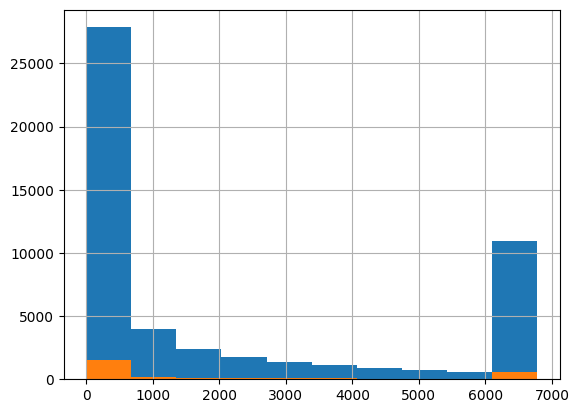

In [29]:
data = 'UNOS'
data_dir = f'../data/{data}'
data_dir = "C:\\Users\\AM000098\\OneDrive - Vrije Universiteit Brussel\\Bureaublad\\Lenovo\\ITE\\AllSim\\src\\myallsim\\data\\my_destination_synth"

if data == 'UNOS':
    dm = myUNOSDataModule(data_dir,is_synth = True, batch_size=256)
    groups_r = [['ALCOHOL_HEAVY_DON_N', 'ALCOHOL_HEAVY_DON_U', 'ALCOHOL_HEAVY_DON_Y'],
                ['COD_CAD_DON_1.0', 'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0', 'COD_CAD_DON_999.0'],
                ['DON_TY_C'], 
                ['ETHCAT_DON_1.0', 'ETHCAT_DON_2.0', 'ETHCAT_DON_4.0', 'ETHCAT_DON_5.0', 'ETHCAT_DON_6.0', 'ETHCAT_DON_7.0', 'ETHCAT_DON_9.0'], 
                ['GENDER_DON_F','GENDER_DON_M'],
                ['HIST_CANCER_DON_N', 'HIST_CANCER_DON_U', 'HIST_CANCER_DON_Y'],
                ['HIST_CIG_DON_N', 'HIST_CIG_DON_U', 'HIST_CIG_DON_Y'],
                ['NON_HRT_DON_N', 'NON_HRT_DON_Y']]
    groups_x = [
        ['DIAG_0.0', 'DIAG_1.0', 'DIAG_10.0', 'DIAG_11.0', 'DIAG_12.0', 'DIAG_13.0', 'DIAG_14.0', 'DIAG_15.0', 'DIAG_16.0',
       'DIAG_17.0', 'DIAG_18.0', 'DIAG_2.0', 'DIAG_3.0', 'DIAG_4.0',
       'DIAG_5.0', 'DIAG_6.0', 'DIAG_7.0', 'DIAG_8.0', 'DIAG_9.0'],
        ['ETHCAT_1.0', 'ETHCAT_2.0', 'ETHCAT_4.0', 'ETHCAT_5.0', 'ETHCAT_6.0', 'ETHCAT_7.0', 'ETHCAT_9.0'],
        ['GENDER_F', 'GENDER_M'],
        ['INIT_ASCITES_1.0', 'INIT_ASCITES_2.0', 'INIT_ASCITES_3.0', 'INIT_ASCITES_4.0'],
    ]

dm.prepare_data()
dm.setup(stage='fit')

DATA = pd.concat([dm._test_processed.copy(deep=True), dm._train_processed.copy(deep=True)])
DATA_true = DATA.copy(deep=True)
DATA_true[dm.real_cols] = dm.scaler.inverse_transform(
    DATA_true[dm.real_cols])

patients = DATA_true[dm.x_cols].copy(deep=True)
organs = DATA_true[dm.o_cols].copy(deep=True)

X = patients
O = organs
Y = dm._train_processed.Y


O_indices_in_real_cols = np.where(np.in1d(np.unique(dm.real_cols), O.columns.values))[0]
mean_real_cols_O = dm.scaler.mean_[O_indices_in_real_cols]
scale_real_cols_O = dm.scaler.scale_[O_indices_in_real_cols]
real_cols_indices_in_O = np.where(np.in1d(O.columns.values, np.unique(dm.real_cols)))[0]

X_indices_in_real_cols = np.where(np.in1d(np.unique(dm.real_cols), X.columns.values))[0]
mean_real_cols_X = dm.scaler.mean_[X_indices_in_real_cols]
scale_real_cols_X = dm.scaler.scale_[X_indices_in_real_cols]
real_cols_indices_in_X = np.where(np.in1d(X.columns.values, np.unique(dm.real_cols)))[0]

In [30]:
O

,AGE_DON,ALCOHOL_HEAVY_DON_N,ALCOHOL_HEAVY_DON_U,ALCOHOL_HEAVY_DON_Y,BMI_DON_CALC,COD_CAD_DON_1.0,COD_CAD_DON_2.0,COD_CAD_DON_3.0,COD_CAD_DON_4.0,COD_CAD_DON_999.0,...,GENDER_DON_M,HGT_CM_DON_CALC,HIST_CANCER_DON_N,HIST_CANCER_DON_U,HIST_CANCER_DON_Y,HIST_CIG_DON_N,HIST_CIG_DON_U,HIST_CIG_DON_Y,NON_HRT_DON_N,NON_HRT_DON_Y
0,56.000000,1,0,0,25.780664,0,1,0,0,0,...,1,177.800000,1,0,0,0,0,1,1,0
1,-1.491468,-1,-1,-1,0.277701,-1,-1,-1,-1,-1,...,-1,10.881731,-1,-1,-1,-1,-1,-1,-1,-1
2,69.000000,1,0,0,34.041028,1,0,0,0,0,...,1,183.000000,0,0,1,0,0,1,1,0
3,-1.491468,-1,-1,-1,0.277701,-1,-1,-1,-1,-1,...,-1,10.881731,-1,-1,-1,-1,-1,-1,-1,-1
4,-1.491468,-1,-1,-1,0.277701,-1,-1,-1,-1,-1,...,-1,10.881731,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51657,-1.491468,-1,-1,-1,0.277701,-1,-1,-1,-1,-1,...,-1,10.881731,-1,-1,-1,-1,-1,-1,-1,-1
51658,29.000000,1,0,0,30.622837,0,0,1,0,0,...,0,170.000000,1,0,0,1,0,0,1,0
51659,61.000000,1,0,0,36.962297,0,1,0,0,0,...,0,149.860000,1,0,0,0,0,1,1,0
51660,27.000000,1,0,0,29.086191,0,0,1,0,0,...,1,185.420000,1,0,0,1,0,0,1,0


In [32]:
DATA

,Unnamed: 0,DAYSWAIT_CHRON,HGT_CM_CALC,INIT_AGE,INIT_ALBUMIN,INIT_BILIRUBIN,INIT_BMI_CALC,INIT_INR,INIT_SERUM_CREAT,INIT_SERUM_SODIUM,...,HIST_CIG_DON_-1,HIST_CIG_DON_N,HIST_CIG_DON_U,HIST_CIG_DON_Y,NON_HRT_DON_-1,NON_HRT_DON_N,NON_HRT_DON_Y,Y_SYNTH,CENS,Y_TRUE
0,39989,-0.139967,-0.026930,0.592031,-1.599057,0.436544,-0.084490,0.667570,0.306636,-1.564195,...,0,0,0,1,0,1,0,3419.928478,0.0,1510.0
1,34979,2.198247,-4.335747,-1.112485,0.731352,-1.848837,0.567391,-0.543042,4.435155,0.396259,...,1,-1,-1,-1,1,-1,-1,726.128785,0.0,1369.0
2,29914,0.682061,-0.223339,0.746987,0.003099,-0.307539,1.315627,-0.704984,-0.272975,-0.191877,...,0,0,0,1,0,1,0,6775.000000,0.0,2881.0
3,33032,-0.521551,-4.973098,0.127163,2.624808,1.203359,-0.032295,0.798354,0.518711,0.004168,...,1,-1,-1,-1,1,-1,-1,677.193981,0.0,29.0
4,13618,4.069630,-4.921467,0.282119,0.148749,-0.344150,-0.068875,0.314872,-1.062740,0.200214,...,1,-1,-1,-1,1,-1,-1,84.020078,0.0,2291.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51657,44732,-0.397739,-5.004479,0.282119,2.042206,1.203359,-1.430689,0.451253,0.306636,0.396259,...,1,-1,-1,-1,1,-1,-1,38.951149,0.0,90.0
51658,54343,-0.513432,1.228110,0.979421,-0.433853,0.695257,0.992175,0.140959,-0.066199,-0.976059,...,0,1,0,0,0,1,0,6775.000000,0.0,8.0
51659,38158,-0.578382,0.598119,0.282119,0.440050,-0.382388,0.264493,-0.968984,0.832367,-1.368150,...,0,0,0,1,0,1,0,6190.493159,0.0,1857.0
51660,860,-0.549967,0.443710,0.746987,0.003099,-0.307539,-0.557538,-0.968984,0.743476,-0.583968,...,0,1,0,0,0,1,0,105.579559,0.0,536.0


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name           | Type             | Params
----------------------------------------------------
0 | representation | Sequential       | 2.4 K 
1 | propensity     | Sequential       | 147   
2 | output         | Sequential       | 49    
3 | loss_mse       | MeanSquaredError | 0     
4 | loss_cel       | CrossEntropyLoss | 0     
----------------------------------------------------
2.6 K     Trainable params
0         Non-trainable params
2.6 K     Total params
0.010     Total estimated model params size (MB)


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Metric val_loss - total improved by 0.000 >= min_delta = 0.0. New best score: 0.349


Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Monitored metric val_loss - total did not improve in the last 2 records. Best score: 0.349. Signaling Trainer to stop.


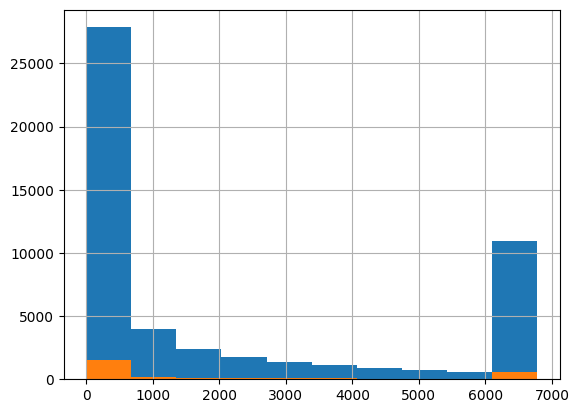

In [33]:
# OrganITE
input_dim = len(dm.o_cols) + len(dm.x_cols)
hidden_dim=16
num_hidden_layers=4
output_dim=6
lr=0.007
gamma=0.79
lambd=0.15
kappa=0.15
weight_decay=0.0006
n_clusters=15
activation_type="leaky_relu"
dropout_prob=0
epochs = 100

organite_model = OrganITE_Network(
             input_dim=input_dim,
             hidden_dim=hidden_dim,
             num_hidden_layers=num_hidden_layers,
             output_dim=output_dim,
             lr=lr,
             gamma=gamma,
             lambd=lambd,
             kappa=kappa,
             weight_decay=weight_decay,
             n_clusters=n_clusters,
             activation_type=activation_type,
             dropout_prob=dropout_prob,
).double()

early_stopping = EarlyStopping('val_loss - total', patience = 2, verbose = True)

organite_trainer = pl.Trainer(callbacks=[early_stopping], max_epochs=epochs)
organite_trainer.fit(organite_model, datamodule=dm)

inference_oite = Inference_OrganITE(
    model=organite_model, mean=dm.mean, std=dm.std,
    x_indices_real=real_cols_indices_in_X, r_indices_real=real_cols_indices_in_O,
    x_mean=mean_real_cols_X, x_scale=scale_real_cols_X,
    r_mean=mean_real_cols_O, r_scale=scale_real_cols_O
)

In [10]:
for i in range(10):
    print(inference_oite.infer(
        np.random.rand(42).reshape(1, -1),
    ))

[[581.83955129]]
[[701.35672064]]
[[669.76711756]]
[[565.16364264]]
[[760.66334375]]
[[709.47939155]]
[[673.67636618]]
[[690.91015061]]
[[755.04702185]]
[[690.20686274]]


In [11]:
for i in range(10):
    print(inference_oite.infer(
        np.random.rand(42).reshape(1, -1),
        np.random.rand(73-43).reshape(1, -1)
    ))

[[753.0031297]]
[[661.47054018]]
[[664.10510121]]
[[683.86587415]]
[[721.53808821]]
[[771.5374698]]
[[785.53931378]]
[[744.99547579]]
[[719.09076685]]
[[697.66769097]]


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃             Test metric             ┃            DataLoader 0             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_loss - RMSE           │         0.01716611348092556         │
│ test_loss - mean difference in days │         26.463537698588258          │
└─────────────────────────────────────┴─────────────────────────────────────┘

[{'test_loss - mean difference in days': 26.463537698588258,
  'test_loss - RMSE': 0.01716611348092556}]

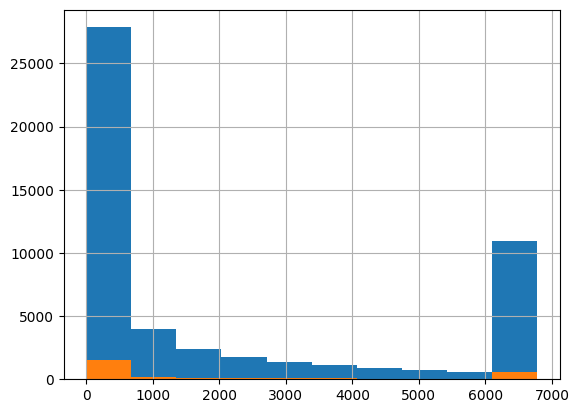

In [34]:
#dm.setup(stage='test')
organite_trainer.test(organite_model, datamodule=dm)

In [12]:
for i in range(10):
    p = np.random.rand(42).reshape(1, -1)
    r = np.random.rand(73-43).reshape(1, -1)
    print(inference_oite.infer(p,r) - inference_oite.infer(p))

[[5.4182322]]
[[3.87321445]]
[[61.48228247]]
[[-0.72155436]]
[[48.10980599]]
[[31.33765112]]
[[81.62095613]]
[[123.15409899]]
[[81.85995894]]
[[100.71893573]]


In [13]:
Y*dm.std + dm.mean

0        2894.582340
1           9.604321
2           2.964234
3          12.036778
4         265.239606
            ...     
51657      38.951149
51658    6775.000000
51659    6190.493159
51660     105.579559
51661    6775.000000
Name: Y, Length: 51662, dtype: float64

In [36]:
O.iloc[0]

AGE_DON                 56.000000
ALCOHOL_HEAVY_DON_N      1.000000
ALCOHOL_HEAVY_DON_U      0.000000
ALCOHOL_HEAVY_DON_Y      0.000000
BMI_DON_CALC            25.780664
COD_CAD_DON_1.0          0.000000
COD_CAD_DON_2.0          1.000000
COD_CAD_DON_3.0          0.000000
COD_CAD_DON_4.0          0.000000
COD_CAD_DON_999.0        0.000000
COLD_ISCH                5.250000
DON_TY_C                 1.000000
ETHCAT_DON_1.0           1.000000
ETHCAT_DON_2.0           0.000000
ETHCAT_DON_4.0           0.000000
ETHCAT_DON_5.0           0.000000
ETHCAT_DON_6.0           0.000000
ETHCAT_DON_7.0           0.000000
ETHCAT_DON_9.0           0.000000
GENDER_DON_F             0.000000
GENDER_DON_M             1.000000
HGT_CM_DON_CALC        177.800000
HIST_CANCER_DON_N        1.000000
HIST_CANCER_DON_U        0.000000
HIST_CANCER_DON_Y        0.000000
HIST_CIG_DON_N           0.000000
HIST_CIG_DON_U           0.000000
HIST_CIG_DON_Y           1.000000
NON_HRT_DON_N            1.000000
NON_HRT_DON_Y 

In [15]:
X.iloc[0]

DAYSWAIT_CHRON       217.000000
DIAG_0.0               0.000000
DIAG_1.0               0.000000
DIAG_10.0              0.000000
DIAG_11.0              0.000000
DIAG_12.0              0.000000
DIAG_13.0              0.000000
DIAG_14.0              0.000000
DIAG_15.0              0.000000
DIAG_16.0              0.000000
DIAG_17.0              0.000000
DIAG_18.0              0.000000
DIAG_2.0               0.000000
DIAG_3.0               0.000000
DIAG_4.0               0.000000
DIAG_5.0               0.000000
DIAG_6.0               1.000000
DIAG_7.0               0.000000
DIAG_8.0               0.000000
DIAG_9.0               0.000000
ETHCAT_1.0             1.000000
ETHCAT_2.0             0.000000
ETHCAT_4.0             0.000000
ETHCAT_5.0             0.000000
ETHCAT_6.0             0.000000
ETHCAT_7.0             0.000000
ETHCAT_9.0             0.000000
GENDER_F               1.000000
GENDER_M               0.000000
HGT_CM_CALC          170.180000
INIT_AGE              62.000000
INIT_ALB

In [37]:
print(inference_oite.infer(np.array([X.iloc[0]])))
print(inference_oite.infer(np.array([X.iloc[0]]), np.array([O.iloc[0]])))

[[410.70805049]]
[[3346.51508846]]


In [48]:
organ_cit_diff_test = np.array([O.iloc[0]])
organ_cit_diff_test[0][10] = 14
print(np.array([O.iloc[0]]))
print(organ_cit_diff_test)

print(inference_oite.infer(np.array([X.iloc[0]])))
print(inference_oite.infer(np.array([X.iloc[0]]), np.array([O.iloc[0]])))
print(inference_oite.infer(np.array([X.iloc[0]]), organ_cit_diff_test))

[[ 56.           1.           0.           0.          25.78066381
    0.           1.           0.           0.           0.
    5.25         1.           1.           0.           0.
    0.           0.           0.           0.           0.
    1.         177.8          1.           0.           0.
    0.           0.           1.           1.           0.        ]]
[[ 56.           1.           0.           0.          25.78066381
    0.           1.           0.           0.           0.
   14.           1.           1.           0.           0.
    0.           0.           0.           0.           0.
    1.         177.8          1.           0.           0.
    0.           0.           1.           1.           0.        ]]
[[410.70805049]]
[[3346.51508846]]
[[406.11832392]]


### KDEs

In [23]:
O.loc[O["DON_TY_C"] == 1].shape

(30911, 30)

In [49]:
kde_o = infer.KDEDensity()
kde_o.fit(O.loc[O["DON_TY_C"] == 1][:10000], one_hot_encoded=groups_r)

In [50]:
kde_o.sample()

,AGE_DON,ALCOHOL_HEAVY_DON_N,ALCOHOL_HEAVY_DON_U,ALCOHOL_HEAVY_DON_Y,BMI_DON_CALC,COD_CAD_DON_1.0,COD_CAD_DON_2.0,COD_CAD_DON_3.0,COD_CAD_DON_4.0,COD_CAD_DON_999.0,...,GENDER_DON_M,HGT_CM_DON_CALC,HIST_CANCER_DON_N,HIST_CANCER_DON_U,HIST_CANCER_DON_Y,HIST_CIG_DON_N,HIST_CIG_DON_U,HIST_CIG_DON_Y,NON_HRT_DON_N,NON_HRT_DON_Y
0,73.980964,0.0,0.0,1.0,24.948899,0.0,1.0,0.0,0.0,0.0,...,1.0,180.737496,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [51]:
X.shape

(54382, 42)

In [52]:
kde_x = infer.KDEDensity()
kde_x.fit(X[:10000], one_hot_encoded=groups_x)

In [53]:
kde_x.sample()

,DAYSWAIT_CHRON,DIAG_0.0,DIAG_1.0,DIAG_10.0,DIAG_11.0,DIAG_12.0,DIAG_13.0,DIAG_14.0,DIAG_15.0,DIAG_16.0,...,INIT_ASCITES_1.0,INIT_ASCITES_2.0,INIT_ASCITES_3.0,INIT_ASCITES_4.0,INIT_BILIRUBIN,INIT_BMI_CALC,INIT_INR,INIT_SERUM_CREAT,INIT_SERUM_SODIUM,WGT_KG_CALC
0,231.873715,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,-1.313524,28.319827,-4.050813,-9.769493,119.105658,75.422358


In [54]:
O.columns

Index(['AGE_DON', 'ALCOHOL_HEAVY_DON_N', 'ALCOHOL_HEAVY_DON_U',
       'ALCOHOL_HEAVY_DON_Y', 'BMI_DON_CALC', 'COD_CAD_DON_1.0',
       'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0',
       'COD_CAD_DON_999.0', 'COLD_ISCH', 'DON_TY_C', 'ETHCAT_DON_1.0',
       'ETHCAT_DON_2.0', 'ETHCAT_DON_4.0', 'ETHCAT_DON_5.0', 'ETHCAT_DON_6.0',
       'ETHCAT_DON_7.0', 'ETHCAT_DON_9.0', 'GENDER_DON_F', 'GENDER_DON_M',
       'HGT_CM_DON_CALC', 'HIST_CANCER_DON_N', 'HIST_CANCER_DON_U',
       'HIST_CANCER_DON_Y', 'HIST_CIG_DON_N', 'HIST_CIG_DON_U',
       'HIST_CIG_DON_Y', 'NON_HRT_DON_N', 'NON_HRT_DON_Y'],
      dtype='object')

In [55]:
X.columns

Index(['DAYSWAIT_CHRON', 'DIAG_0.0', 'DIAG_1.0', 'DIAG_10.0', 'DIAG_11.0',
       'DIAG_12.0', 'DIAG_13.0', 'DIAG_14.0', 'DIAG_15.0', 'DIAG_16.0',
       'DIAG_17.0', 'DIAG_18.0', 'DIAG_2.0', 'DIAG_3.0', 'DIAG_4.0',
       'DIAG_5.0', 'DIAG_6.0', 'DIAG_7.0', 'DIAG_8.0', 'DIAG_9.0',
       'ETHCAT_1.0', 'ETHCAT_2.0', 'ETHCAT_4.0', 'ETHCAT_5.0', 'ETHCAT_6.0',
       'ETHCAT_7.0', 'ETHCAT_9.0', 'GENDER_F', 'GENDER_M', 'HGT_CM_CALC',
       'INIT_AGE', 'INIT_ALBUMIN', 'INIT_ASCITES_1.0', 'INIT_ASCITES_2.0',
       'INIT_ASCITES_3.0', 'INIT_ASCITES_4.0', 'INIT_BILIRUBIN',
       'INIT_BMI_CALC', 'INIT_INR', 'INIT_SERUM_CREAT', 'INIT_SERUM_SODIUM',
       'WGT_KG_CALC'],
      dtype='object')

### Generate Simulated Acceptance dataset

In [306]:
def synth_acceptance(x,o, hmeld = 0.01, hcit = 0.15, hage = 0.22, hbmi = 0.0, hrnd = 1):
    bilirubin = x.INIT_BILIRUBIN
    inr = x.INIT_INR
    serum_creat = x.INIT_SERUM_CREAT
    
    MELD = 3.79 * (bilirubin if bilirubin > 0 else 0) + 11.2 * (inr if inr > 0 else 0) + 9.57 * (serum_creat if serum_creat > 0 else 0) + 6.43
    age_diff = abs(x["INIT_AGE"] - o["AGE_DON"])
    age_diff_cond = 1 if age_diff <= 30 else 0
    bmi_diff = abs(x["INIT_BMI_CALC"] - o["BMI_DON_CALC"])
    bmi_diff_cond = 1 if bmi_diff <= 5 else 0
    cit = o["COLD_ISCH"]
    if MELD > 40:
        MELD = 40
    #tot = MELD  - 2*cit - 5*np.random.rand() - age_diff_cond*20
    MELD_rel = MELD-20
    rnd = np.random.rand() - 0.5
    tot = hmeld*MELD_rel  - hcit*cit - hage*age_diff_cond*20 - hbmi*bmi_diff_cond + hrnd*rnd
    prob = 1/(1+np.exp(-tot))
    return prob

def synth_time(x,o, hh = 8, hsig = 1, hrnd = 0.4):
    acc = synth_acceptance(x,o)
    #time = (-8*acc**2 + 8*acc)
    time = -hh*acc*(acc-1)*np.exp(-(acc-0.5)**2/hsig) + hrnd*np.random.rand()
    return time

In [307]:
## USED POLICY

def MELD_rank(Q):
    # DEFINITION OF (standard) MELD: https://en.wikipedia.org/wiki/Model_for_End-Stage_Liver_Disease#Determination
    bilirubin = Q["INIT_BILIRUBIN"].copy()
    inr = Q["INIT_INR"].copy()
    serum_creat = Q["INIT_SERUM_CREAT"].copy()

    bilirubin[bilirubin < 0] = 0
    inr[inr < 0] = 0
    serum_creat[serum_creat < 0] = 0
    
    Q["MELD"] = 3.79 * bilirubin + 11.2 * inr + 9.57 * serum_creat + 6.43

    Q = Q.sort_values(by='MELD', ascending=False)
    Q = Q.drop("MELD", axis = 1)
    return Q

In [312]:
simulated_acceptance_dataset = pd.DataFrame(columns=list(X.columns) + list(O.columns) + ["ACC", "DEC_TIME"])
chains_lengths = []
org_cits = []

In [313]:
generated_initial_organs = kde_o.sample(n=1000)
generated_initial_organs["COLD_ISCH"] = 0
iter = 0

for organ in generated_initial_organs.iterrows():
    chain = 0
    organ = organ[1]
    ## generate patients for X_Q
    generated_Q = kde_x.sample(n=50)
    ## TODO: sort X_Q based on current policy
    generated_Q = MELD_rank(generated_Q)
    for patient in generated_Q.iterrows():
        chain += 1
        patient = patient[1]
        accept = synth_acceptance(patient,organ)
        print(accept)
        time = synth_time(patient,organ)
        ## update CIT
        organ["COLD_ISCH"] += time
        XO = dict(organ) | dict(patient)
        if accept > np.random.rand():
            ## organ got accepted: add to obs, break sim
            simulated_acceptance_dataset.loc[len(simulated_acceptance_dataset)] = XO | {"ACC": 1, "DEC_TIME": time}
            break
        else:
            ## organ got rejected: add to obs, continue sim
            simulated_acceptance_dataset.loc[len(simulated_acceptance_dataset)] = XO | {"ACC": 0, "DEC_TIME": time}
    chains_lengths.append(chain)
    org_cits.append(organ["COLD_ISCH"])
    iter += 1
    print("Sim number: ", iter)
        

0.012151838363578681
0.022351831653676865
0.0085794886529514
0.008886901418566665
0.009260772163260393
0.007272573527665743
0.011444572922587801
0.00792248405659285
0.01379256295243485
0.006202732526028479
0.012890937931874525
0.012206149650757562
0.010175544036937578
0.008650366499859997
0.00774244582042525
0.009411972217452156
0.010664769309508007
0.007456887981273073
0.005953583682906323
0.004325193347694773
0.006475925544185593
0.00782534746780565
0.00790285342019574
0.0062412726587004605
0.37200285109788955
0.0034249007721194502
0.0062869545275879846
0.0037147701694223473
0.006135464744408942
0.004826886320284683
0.002414706822494699
0.005110297263294325
0.004638775855280227
0.00222929954639631
0.002894302699137526
0.003263132081206787
0.002458265188471473
0.00339823795272169
0.002305903897377195
0.0014790745525335568
0.0022333790950886416
0.002477877767774615
0.001926086631564826
0.002143393728770133
0.002686107977801907
0.0024128879526488086
0.0013395954822934455
0.0014774986509

In [319]:
simulated_acceptance_dataset[["ACC","COLD_ISCH"]].shape

(18945, 2)

In [314]:
simulated_acceptance_dataset[["ACC","COLD_ISCH"]].mean()

ACC          0.040116
COLD_ISCH    6.665932
dtype: float64

18.945
19.65843266895914


[]

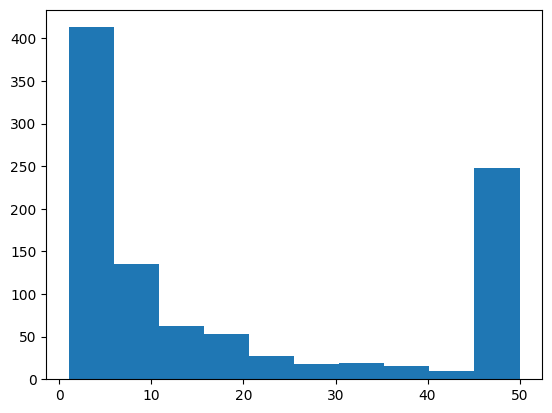

In [315]:
print(np.mean(chains_lengths))
print(np.std(chains_lengths))
plt.hist(chains_lengths)
plt.plot()

In [92]:
org_cits

[4.051748586222533,
 5.6767408071377865,
 2.0272132002472927,
 5.722186567306128,
 3.4656370227535227,
 3.7913041742801976,
 3.9407941083166422,
 1.6236717828040992,
 1.7259019059460343,
 1.7571591514617089,
 3.6686465858239936,
 0.007065202584278986,
 3.9276858538348582,
 5.911885908135082,
 0.11719924255693893,
 1.984150309698571,
 1.6601595718493307,
 1.9797824611279713,
 3.636960893976543,
 1.9624914696535412,
 1.6382621899862155,
 5.7958479525981454,
 2.0008075741395652,
 5.736179970217825,
 1.824713442711416,
 6.019434214838624,
 1.9917838846547165,
 1.6832120179651864,
 3.983650766027324,
 0.022571927434646016,
 3.80147859046538,
 1.7499342914838794,
 3.7888482763038622,
 0.10138857131218093,
 1.6884314514024434,
 1.9405145473376644,
 1.9844412290732085,
 1.715722662880837,
 3.9726369544461404,
 2.0952073765934176,
 1.631883768793669,
 1.6827671454008872,
 1.6832903119244493,
 5.546870392316759,
 1.6625708619603705,
 3.815195502059386,
 1.7082804745052012,
 3.434257514224074,
 1

7.478862539781068
5.383572230090368


[]

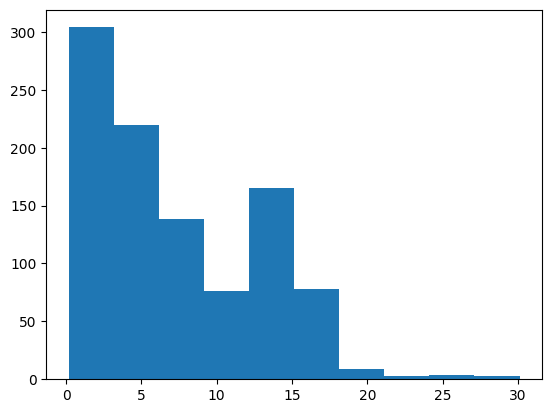

In [316]:
print(np.mean(org_cits))
print(np.std(org_cits))
plt.hist(org_cits)
plt.plot()

In [101]:
print(len(chains_lengths))

144


In [321]:
simulated_acceptance_dataset.columns

Index(['DAYSWAIT_CHRON', 'DIAG_0.0', 'DIAG_1.0', 'DIAG_10.0', 'DIAG_11.0',
       'DIAG_12.0', 'DIAG_13.0', 'DIAG_14.0', 'DIAG_15.0', 'DIAG_16.0',
       'DIAG_17.0', 'DIAG_18.0', 'DIAG_2.0', 'DIAG_3.0', 'DIAG_4.0',
       'DIAG_5.0', 'DIAG_6.0', 'DIAG_7.0', 'DIAG_8.0', 'DIAG_9.0',
       'ETHCAT_1.0', 'ETHCAT_2.0', 'ETHCAT_4.0', 'ETHCAT_5.0', 'ETHCAT_6.0',
       'ETHCAT_7.0', 'ETHCAT_9.0', 'GENDER_F', 'GENDER_M', 'HGT_CM_CALC',
       'INIT_AGE', 'INIT_ALBUMIN', 'INIT_ASCITES_1.0', 'INIT_ASCITES_2.0',
       'INIT_ASCITES_3.0', 'INIT_ASCITES_4.0', 'INIT_BILIRUBIN',
       'INIT_BMI_CALC', 'INIT_INR', 'INIT_SERUM_CREAT', 'INIT_SERUM_SODIUM',
       'WGT_KG_CALC', 'AGE_DON', 'ALCOHOL_HEAVY_DON_N', 'ALCOHOL_HEAVY_DON_U',
       'ALCOHOL_HEAVY_DON_Y', 'BMI_DON_CALC', 'COD_CAD_DON_1.0',
       'COD_CAD_DON_2.0', 'COD_CAD_DON_3.0', 'COD_CAD_DON_4.0',
       'COD_CAD_DON_999.0', 'COLD_ISCH', 'DON_TY_C', 'ETHCAT_DON_1.0',
       'ETHCAT_DON_2.0', 'ETHCAT_DON_4.0', 'ETHCAT_DON_5.0', 'ETHCAT_D

In [325]:
destination = "my_acceptance_data"

In [327]:
train, test = train_test_split(simulated_acceptance_dataset, test_size=0.05)
simulated_acceptance_dataset.to_csv(f"{destination}/acceptance_data_synth.csv")
train.to_csv(f"{destination}/acceptance_data_synth_train.csv")
test.to_csv(f"{destination}/acceptance_data_synth_test.csv")

### 2nd ACC DATASET

In [347]:
def synth_acceptance2(x,o, hmeld = 0.01, hcit = 0.15, hage = 0.22, hbmi = 0.0, hrnd = 1):
    bilirubin = x.INIT_BILIRUBIN
    inr = x.INIT_INR
    serum_creat = x.INIT_SERUM_CREAT
    
    MELD = 3.79 * (bilirubin if bilirubin > 0 else 0) + 11.2 * (inr if inr > 0 else 0) + 9.57 * (serum_creat if serum_creat > 0 else 0) + 6.43
    age_diff = abs(x["INIT_AGE"] - o["AGE_DON"])
    age_diff_cond = 1 if age_diff <= 30 else 0
    bmi_diff = abs(x["INIT_BMI_CALC"] - o["BMI_DON_CALC"])
    bmi_diff_cond = 1 if bmi_diff <= 5 else 0
    cit = o["COLD_ISCH"]
    if MELD > 40:
        MELD = 40
    #tot = MELD  - 2*cit - 5*np.random.rand() - age_diff_cond*20
    MELD_rel = MELD-20
    rnd = np.random.rand() - 0.5
    tot = hmeld*MELD_rel  - hcit*cit - hage*age_diff_cond*20 - hbmi*bmi_diff_cond + hrnd*rnd
    prob = 1/(1+np.exp(-tot))
    return prob

def synth_time2(x,o, hh = 8, hsig = 1, hrnd = 0.4):
    acc = synth_acceptance(x,o)
    #time = (-8*acc**2 + 8*acc)
    time = -hh*acc*(acc-1)*np.exp(-(acc-0.5)**2/hsig) + hrnd*np.random.rand()
    return time

In [356]:
simulated_acceptance_dataset2 = pd.DataFrame(columns=list(X.columns) + list(O.columns) + ["ACC", "DEC_TIME"])
chains_lengths2 = []
org_cits2 = []

In [357]:
generated_initial_organs2 = kde_o.sample(n=10000)
generated_initial_organs2["COLD_ISCH"] = 0
iter = 0

for organ in generated_initial_organs2.iterrows():
    chain = 0
    organ = organ[1]
    ## generate patients for X_Q
    generated_Q = kde_x.sample(n=50)
    ## TODO: sort X_Q based on current policy
    generated_Q = MELD_rank(generated_Q)
    for patient in generated_Q.iterrows():
        chain += 1
        patient = patient[1]
        accept = synth_acceptance2(patient,organ)
        #print(accept)
        time = synth_time2(patient,organ)
        ## update CIT
        organ["COLD_ISCH"] += time
        XO = dict(organ) | dict(patient)
        if accept > np.random.rand():
            ## organ got accepted: add to obs, break sim
            simulated_acceptance_dataset2.loc[len(simulated_acceptance_dataset2)] = XO | {"ACC": 1, "DEC_TIME": time}
            break
        else:
            ## organ got rejected: add to obs, continue sim
            simulated_acceptance_dataset2.loc[len(simulated_acceptance_dataset2)] = XO | {"ACC": 0, "DEC_TIME": time}
    chains_lengths2.append(chain)
    org_cits2.append(organ["COLD_ISCH"])
    iter += 1
    #print(simulated_acceptance_dataset2[["ACC","COLD_ISCH"]].mean())
    print("Sim number: ", iter)

Sim number:  1
Sim number:  2
Sim number:  3
Sim number:  4
Sim number:  5
Sim number:  6
Sim number:  7
Sim number:  8
Sim number:  9
Sim number:  10
Sim number:  11
Sim number:  12
Sim number:  13
Sim number:  14
Sim number:  15
Sim number:  16
Sim number:  17
Sim number:  18
Sim number:  19
Sim number:  20
Sim number:  21
Sim number:  22
Sim number:  23
Sim number:  24
Sim number:  25
Sim number:  26
Sim number:  27
Sim number:  28
Sim number:  29
Sim number:  30
Sim number:  31
Sim number:  32
Sim number:  33
Sim number:  34
Sim number:  35
Sim number:  36
Sim number:  37
Sim number:  38
Sim number:  39
Sim number:  40
Sim number:  41
Sim number:  42
Sim number:  43
Sim number:  44
Sim number:  45
Sim number:  46
Sim number:  47
Sim number:  48
Sim number:  49
Sim number:  50
Sim number:  51
Sim number:  52
Sim number:  53
Sim number:  54
Sim number:  55
Sim number:  56
Sim number:  57
Sim number:  58
Sim number:  59
Sim number:  60
Sim number:  61
Sim number:  62
Sim number:  63
S

In [358]:
simulated_acceptance_dataset2[["ACC","COLD_ISCH"]].mean()

ACC          0.043020
COLD_ISCH    6.577788
dtype: float64

18.1567
19.196800387304133


[]

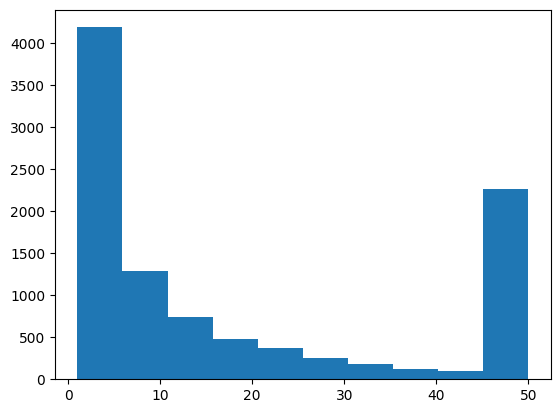

In [360]:
print(np.mean(chains_lengths2))
print(np.std(chains_lengths2))
plt.hist(chains_lengths2)
plt.plot()

7.198295896686398
5.3841714208053135


[]

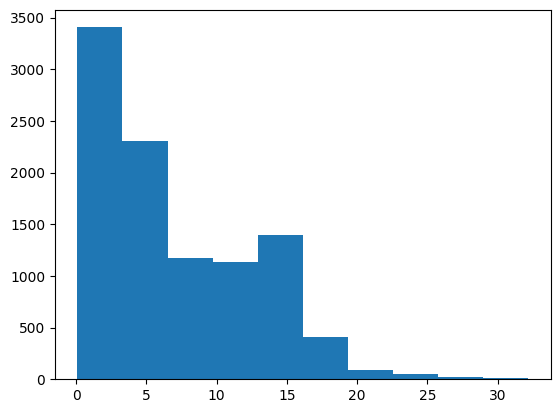

In [361]:
print(np.mean(org_cits2))
print(np.std(org_cits2))
plt.hist(org_cits2)
plt.plot()

In [362]:
destination2 = "my_acceptance_data_BIG"

In [363]:
train2, test2 = train_test_split(simulated_acceptance_dataset2, test_size=0.05)
simulated_acceptance_dataset2.to_csv(f"{destination2}/acceptance_data_synth_BIG.csv")
train2.to_csv(f"{destination2}/acceptance_data_synth_BIG_train.csv")
test2.to_csv(f"{destination2}/acceptance_data_synth_BIG_test.csv")